# Sales Data Analysis with NumPy, Pandas and Matplotlib

This project analyzes a large synthetic retail sales dataset using **NumPy, Pandas and Matplotlib**. It demonstrates data loading, cleaning, aggregation, statistical calculations and multiple visualizations.

**Charts covered:** bar graph, pie chart, scatter plot, histogram, line graph and subplots. Each chart is also saved as a PNG file in the `plots/` folder.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


## 1. Load the sales data

In [6]:
# In Google Colab, upload sales_data.csv first, then run this cell.
# If the CSV is inside a data folder, use: pd.read_csv('/content/data/sales_data.csv')
df = pd.read_csv('/content/sales_data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.head()


,Order_Date,Order_ID,Region,State,Category,Product,Quantity,Discount,Sales,Profit,Payment_Method,Customer_Segment
0,2024-01-01,ORD-10075,North,Uttar Pradesh,Electronics,Smartphone,2,0.10,70079.17,8365.05,Cash,Small Business
1,2024-01-02,ORD-10859,West,Goa,Furniture,Desk,3,0.05,75564.02,6084.04,Credit Card,Corporate
2,2024-01-02,ORD-11280,West,Gujarat,Electronics,Laptop,7,0.10,338381.85,82196.73,Credit Card,Corporate
3,2024-01-03,ORD-11188,North,Haryana,Office Supplies,Pen Set,3,0.05,1012.87,229.84,UPI,Corporate
4,2024-01-04,ORD-10132,South,Kerala,Home Appliances,Electric Kettle,7,0.10,6422.73,1165.55,Debit Card,Small Business


## 2. Explore the dataset with Pandas

In [7]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nSummary statistics:')
display(df.describe(include='all').T)


Shape: (1500, 12)

Columns: ['Order_Date', 'Order_ID', 'Region', 'State', 'Category', 'Product', 'Quantity', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Customer_Segment']

Data types:
Order_Date          datetime64[ns]
Order_ID                    object
Region                      object
State                       object
Category                    object
Product                     object
Quantity                     int64
Discount                   float64
Sales                      float64
Profit                     float64
Payment_Method              object
Customer_Segment            object
dtype: object

Missing values:
Order_Date          0
Order_ID            0
Region              0
State               0
Category            0
Product             0
Quantity            0
Discount            0
Sales               0
Profit              0
Payment_Method      0
Customer_Segment    0
dtype: int64

Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_Date,1500,NaN,NaN,NaN,2024-12-28 01:39:50.399999744,2024-01-01 00:00:00,2024-06-22 18:00:00,2024-12-31 00:00:00,2025-06-24 00:00:00,2025-12-31 00:00:00,NaN
Order_ID,1500,1500,ORD-11032,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,1500,5,West,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1500,18,Uttar Pradesh,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1500,4,Electronics,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1500,16,Laptop,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1500.0,NaN,NaN,NaN,4.084667,1.0,2.0,4.0,6.0,7.0,1.973515
Discount,1500.0,NaN,NaN,NaN,0.081867,0.0,0.05,0.1,0.1,0.2,0.056833
Sales,1500.0,NaN,NaN,NaN,57915.189407,76.58,3535.8925,24754.64,71301.3975,609698.52,85737.483825
Profit,1500.0,NaN,NaN,NaN,8626.115567,11.29,507.7025,3261.035,10350.845,99450.56,13886.05918


## 3. NumPy calculations

In [8]:
sales_array = df['Sales'].to_numpy()
profit_array = df['Profit'].to_numpy()

print('Total Sales:', np.round(np.sum(sales_array), 2))
print('Average Sale:', np.round(np.mean(sales_array), 2))
print('Maximum Sale:', np.round(np.max(sales_array), 2))
print('Minimum Sale:', np.round(np.min(sales_array), 2))
print('Sales Standard Deviation:', np.round(np.std(sales_array), 2))
print('Total Profit:', np.round(np.sum(profit_array), 2))


Total Sales: 86872784.11
Average Sale: 57915.19
Maximum Sale: 609698.52
Minimum Sale: 76.58
Sales Standard Deviation: 85708.9
Total Profit: 12939173.35


## 4. Bar graph — Sales by Region

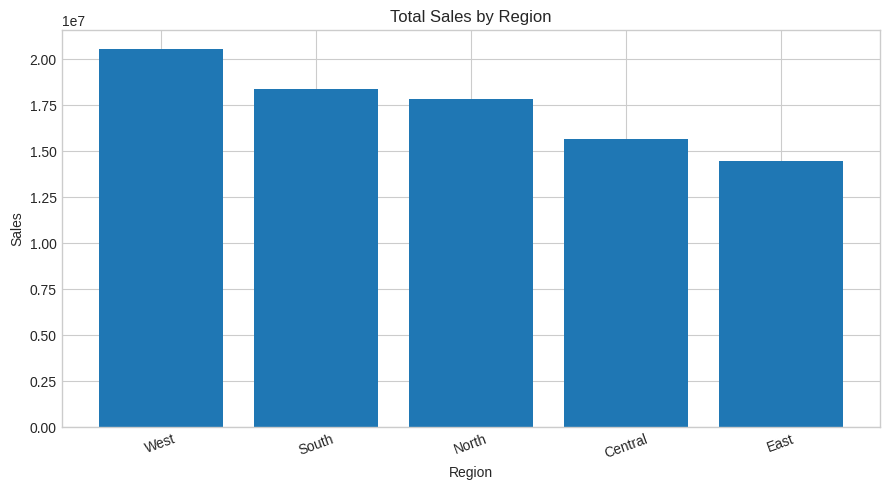

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
plt.bar(region_sales.index, region_sales.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('/content/plots/sales_by_region_bar.png', dpi=150)
plt.show()


## 5. Pie chart — Sales by Category

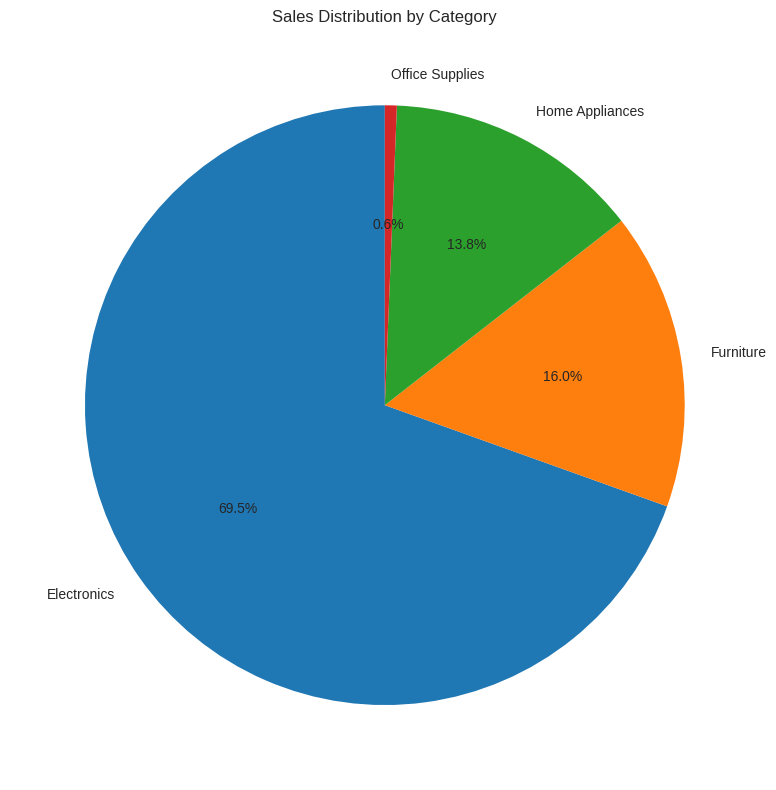

In [16]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,8))
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Category')
plt.tight_layout()
plt.savefig('/content/plots/sales_by_category_pie.png', dpi=150)
plt.show()


## 6. Scatter plot — Sales vs Profit

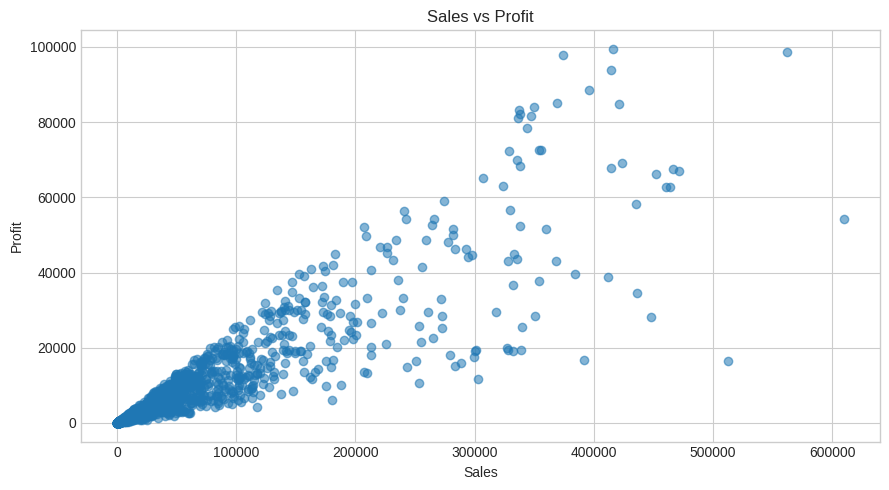

In [17]:
plt.figure(figsize=(9,5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.55)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.savefig('/content/plots/sales_vs_profit_scatter.png', dpi=150)
plt.show()


## 7. Histogram — Distribution of Sales

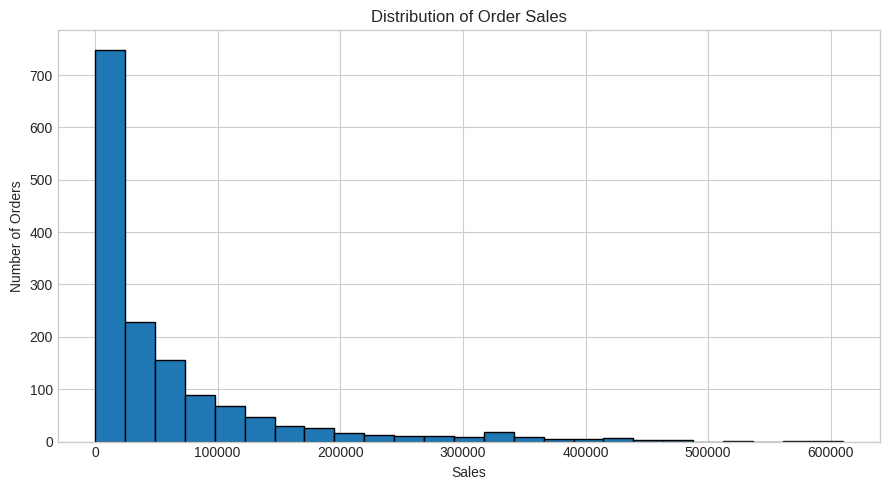

In [18]:
plt.figure(figsize=(9,5))
plt.hist(df['Sales'], bins=25, edgecolor='black')
plt.title('Distribution of Order Sales')
plt.xlabel('Sales')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('/content/plots/sales_histogram.png', dpi=150)
plt.show()


## 8. Line graph — Monthly Sales Trend

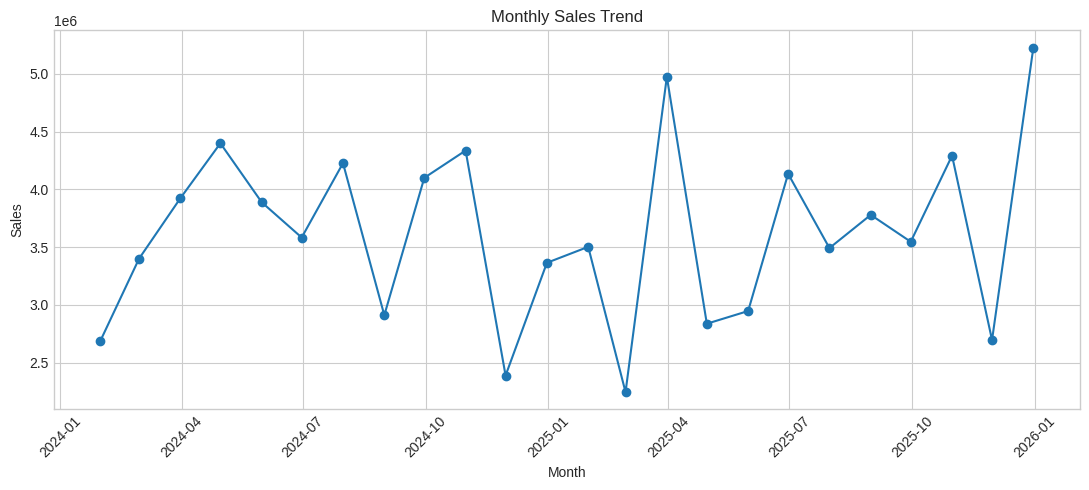

In [19]:
monthly_sales = df.set_index('Order_Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(11,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/plots/monthly_sales_line.png', dpi=150)
plt.show()


## 9. Subplots — Sales, Profit and Quantity by Category

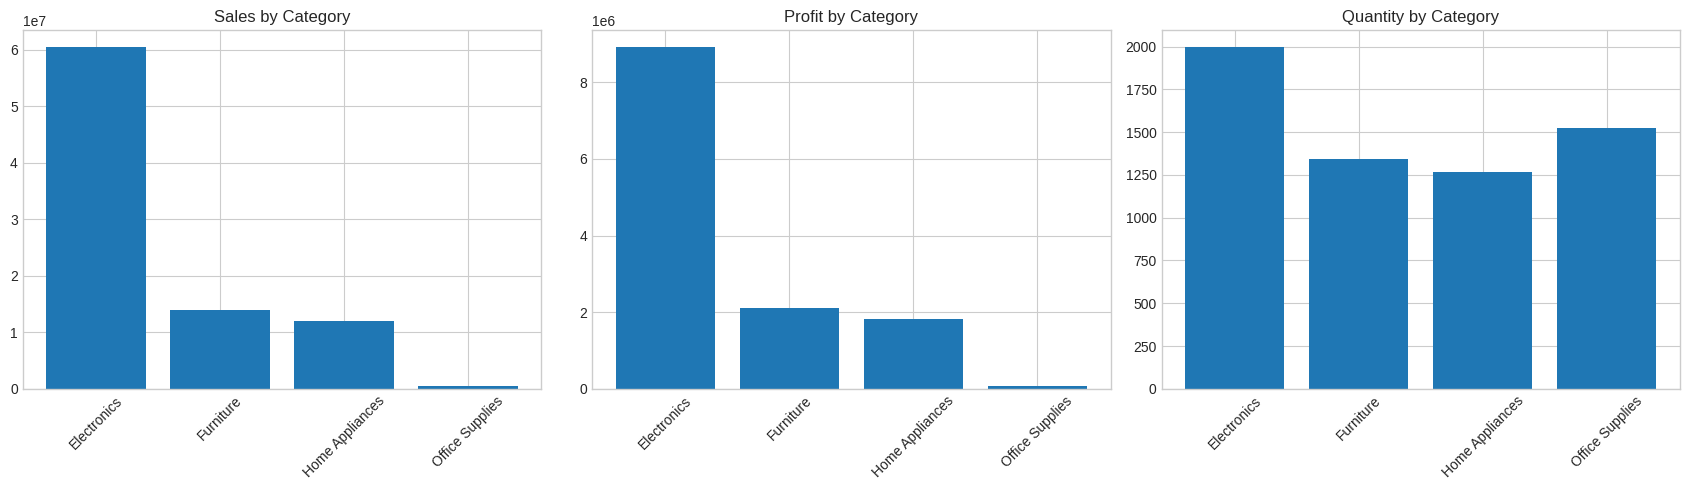

In [20]:
category_summary = df.groupby('Category').agg({'Sales':'sum', 'Profit':'sum', 'Quantity':'sum'})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].bar(category_summary.index, category_summary['Sales'])
axes[0].set_title('Sales by Category')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(category_summary.index, category_summary['Profit'])
axes[1].set_title('Profit by Category')
axes[1].tick_params(axis='x', rotation=45)
axes[2].bar(category_summary.index, category_summary['Quantity'])
axes[2].set_title('Quantity by Category')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/content/plots/category_subplots.png', dpi=150)
plt.show()


## 10. Additional analysis — Top 10 products

,Total Sales
Product,
Laptop,32396108.75
Smartphone,14888293.93
Monitor,10239924.44
Microwave,5820533.85
Desk,4958117.93
Office Chair,4491520.21
Air Cooler,4238416.38
Bookshelf,3578686.50
Headphones,2870915.83


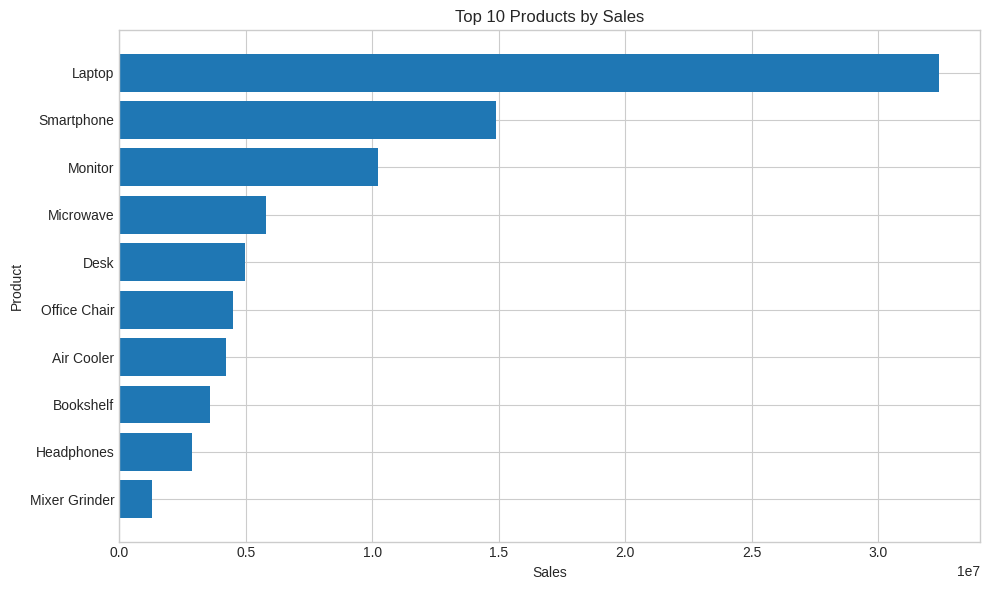

In [21]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)
display(top_products.to_frame('Total Sales'))

plt.figure(figsize=(10,6))
plt.barh(top_products.index[::-1], top_products.values[::-1])
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('/content/plots/top_10_products.png', dpi=150)
plt.show()


## 11. Save the processed summary

In [22]:
category_summary.to_csv('/content/category_summary.csv')
monthly_sales.to_csv('/content/monthly_sales.csv')
print('Summary files saved successfully.')


Summary files saved successfully.
